<a href="https://colab.research.google.com/github/bruno-vieira2512/Data_Science/blob/main/11_Analisando_Dados_Airbnb_(Mallorca).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><img alt="Analisando Airbnb" width="35%" src="https://cdn.prod.website-files.com/6047a9e35e5dc54ac86ddd90/6387b574438cb34f02fcf8c7_8QxOTbpyisEwldvyhwvfa_LhpqNLyGmJagh6i7fTgqg-p-800.png"></center>

# Análise dos Dados do Airbnb - Mallorca

O [Airbnb](https://www.airbnb.com.br/) já é considerado como sendo a **maior empresa hoteleira da atualidade**, mais conhecida e inovadora do setor de turismo, tendo revolucionado a forma como as pessoas viajam e encontram acomodações. Ah, o detalhe é que ele **não possui nenhum hotel**!

Conectando pessoas que querem viajar (e se hospedar) com anfitriões que querem alugar seus imóveis de maneira prática, o Airbnb fornece uma plataforma inovadora para tornar essa hospedagem alternativa.

No final de 2018, a Startup fundada 10 anos atrás, já havia **hospedado mais de 300 milhões** de pessoas ao redor de todo o mundo, desafiando as redes hoteleiras tradicionais. A plataforma possui milhões de anúncios ativos em mais de 220 países e regiões ao redor do mundo, e ganha dinheiro cobrando taxas de serviços sobre transações (uma taxa do hóspede e outra taxa do anfitrião).

Uma das iniciativas do Airbnb é disponibilizar dados do site, para algumas das principais cidades do mundo. Por meio do portal [Inside Airbnb](http://insideairbnb.com/get-the-data.html), é possível baixar uma grande quantidade de dados para desenvolver projetos e soluções de *Data Science*.

#### **Mallorca**
Mallorca é a maior das Ilhas Baleares da Espanha, destacando-se por praias de águas azul-turquesa com enseadas rochosas, montanhas para trilhas (Serra de Tramuntana) e uma rica cultura medieval com destaque para a Catedral de Palma. É um destino popular na Europa o ano todo sendo intensamento movimentado e ensolarado de Abril a Outubro.

A capital Palma possui um centro histórico rico e oferece uma atmosfera animada especialmente em áreas turísticas. Em relação a locomoção, recomenda-se alugar um carro com antecedência para explorar a ilha com mais autonomia e em relação a acessibilidade, Mallorca destaca-se por ser um destino familiar, com boa infraestrutura, mas o excesso de turismo é uma preocupação, com protestos locais registrados. A ilha recebe anualmente cerca de 3 milhões de turistas, dos quais cerca de 750 mil são provenientes do Reino Unido.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Esse comando ajuda a renderizar os gráficos deixando-os dentro da célula
%matplotlib inline

# Configurações para melhora a visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',100)
pd.set_option('display.float_format','{:.2f}'.format)
warnings.filterwarnings('ignore')

# Configuração visual dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size']= 10

In [2]:
url = 'https://data.insideairbnb.com/spain/islas-baleares/mallorca/2025-09-21/visualisations/listings.csv'
df = pd.read_csv(url)

# Vamos copiar o dataframe para manter o original
df_original = df.copy()

In [3]:
# Visualizando uma pequena amostra dos dados
print(f'Total de linhas: {len(df_original)}')
print(f'Total de colunas: {len(df_original.columns)}')

Total de linhas: 15034
Total de colunas: 18


In [4]:
# Visualizar as primeiras 3 linhas
df_original.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,69998,WFH loft… Hideaway xperience in Palma old town,353156,Lor,NaN,Palma de Mallorca,39.57,2.65,Entire home/apt,164.00,32,266,2025-06-27,1.60,2,309,2,NaN
1,106833,Villa with a big pool in Mallorca,551974,Xisco,NaN,Sant Llorenç des Cardassar,39.61,3.30,Entire home/apt,200.00,5,32,2025-09-02,0.20,1,5,5,ESFCTU00A00702300107013400000000000000000000ET...
2,159218,Farmhouse in Nature -ETV-3025,763897,Gabriel,NaN,Selva,39.79,2.91,Entire home/apt,160.00,4,407,2025-09-20,2.38,2,308,28,ESFCTU00000702200009178200000000000000000000ET...


In [5]:
# Visualizar as últimas 3 linhas
df_original.tail(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
15031,1513826114343023704,Ewave Mountain Studio,133518187,Jasmina Margarete,NaN,Puigpunyent,39.63,2.53,Entire home/apt,51.00,1,0,NaN,NaN,62,333,0,ESFCNT0000070320000715850000000000000000000000...
15032,1513878239514288608,Es Rafal De Baix,674120741,Michael,NaN,Son Servera,39.66,3.37,Entire home/apt,9000.00,1,0,NaN,NaN,135,364,0,ETV/3090
15033,1513880348430843626,Villa Cadell Petit,431977102,Michael,NaN,Sa Pobla,39.81,3.03,Entire home/apt,10000.00,1,0,NaN,NaN,65,364,0,ESFCTU000007030000268035000000000000000000000E...


In [6]:
# Amostra aleatória com 3 linhas e o parâmetro random_state é uma semente aleatória
df_original.sample(3,random_state=42)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
2021,17846638,Beautiful Villa and Garden with Full Amenities,89068267,Diego,NaN,Campos,39.45,3.00,Entire home/apt,269.00,5,81,2025-08-23,0.80,1,36,19,ESFCTU00000700800037097300000000000000000000ET...
12196,1255085470703069119,Schönes Landhaus in der Nähe von Manacor mit P...,577475733,Pavel,NaN,Manacor,39.60,3.19,Entire home/apt,8000.00,1,0,NaN,NaN,131,116,0,ESFCTU00000702300051737100000000000000000000ET...
4359,32800024,Peña Rubia by Interhome,118494447,Rebekka - Interhome Group,NaN,Manacor,39.46,3.26,Entire home/apt,168.00,1,4,2025-05-29,0.07,19,229,1,NaN


## Porque as três visualizações acima?

- **head()**: Verifica se o arquivo foi lido corretamente.
- **tail()**: Detecta problemas no final do arquivo (linhas vazias, rodapés indesejados.
- **sample()**: Mostra dados do meio do dataset que podem ser diferentes do início.

In [7]:
# Resumo conciso e estrutural do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15034 entries, 0 to 15033
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              15034 non-null  int64  
 1   name                            15034 non-null  object 
 2   host_id                         15034 non-null  int64  
 3   host_name                       15029 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   15034 non-null  object 
 6   latitude                        15034 non-null  float64
 7   longitude                       15034 non-null  float64
 8   room_type                       15034 non-null  object 
 9   price                           15027 non-null  float64
 10  minimum_nights                  15034 non-null  int64  
 11  number_of_reviews               15034 non-null  int64  
 12  last_review                     

# **1 - Análise de Dados**

Dicionário de Dados

*   `id` - Identificador exclusivo (ID) do anúncio no Airbnb.
*   `name` - Nome do anúncio (título que o anfitrião deu à propriedade).
*   `host_id` - Identificador exclusivo (ID) do anfitrião (proprietário do anúncio).
*   `host_name` - Nome do anfitrião.
*   `neighbourhood_group` - Agrupamento de bairros. (Esta coluna pode estar vazia ou conter dados não válidos em algumas cidades, dependendo de como o Inside Airbnb classifica a região).
*   `neighbourhood` - O bairro onde a propriedade está localizada.
*   `latitude` - Coordenada de latitude da propriedade.
*   `longitude` - Coordenada de longitude da propriedade.
*   `room_type` - Tipo de espaço alugado (Casa/Apto inteiro, Quarto Privado e etc).
*   `price` - O preço diário para alugar a acomodação (na moeda local, mas neste caso é EUR).
*   `minimum_nights` - O número mínimo de noites que o hóspede deve reservar.
*   `number_of_reviews` - Número total de avaliações que o anúncio recebeu.
*   `last_review` - A data da avaliação mais recente.
*   `reviews_per_month` - A média de avaliações por mês (calculada).
*   `calculated_host_listings_count` - O número de anúncios que o anfitrião possui nesta mesma cidade/região.
*   `availability_365` - O número de dias disponíveis para reserva no próximo ano (365 dias).
*   `number_of_reviews_ltm` - Número de avaliações no Last Twelve Months (últimos 12 meses).
*   `license` - Informação sobre a licença (se aplicável), especialmente relevante em locais com regulamentação estrita.

### **1.1 - Quantidade de entradas e variáveis do nosso dataframe.**

In [8]:
# Nesse momento vamos verificar o volume de dados do Dataframe
# para identificar a quantidade de entradas e as variáveis

print(f'Entradas: {df_original.shape[0]}')
print(f'Variáveis: {df_original.shape[1]}')

# Verificar o tipo de dados das colunas do dataset
display(df_original.dtypes)

Entradas: 15034
Variáveis: 18


,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,float64
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


# **2 - Estatística Descritiva**

In [9]:
# Estatística Descritiva incluíndo variáveis categóricas
df_original.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,15034.00,15034.00,0.00,15034.00,15034.00,15027.00,15034.00,15034.00,12124.00,15034.00,15034.00,15034.00
mean,531592232985330304.00,209326749.89,NaN,39.66,3.01,1512.97,4.12,26.53,0.76,84.05,209.13,6.22
std,584904990114609280.00,204345327.72,NaN,0.17,0.24,3047.83,9.56,56.17,1.51,172.15,119.90,13.41
min,69998.00,18651.00,NaN,39.30,2.35,10.00,1.00,0.00,0.01,1.00,0.00,0.00
25%,28256285.75,49501915.00,NaN,39.53,2.90,170.00,1.00,1.00,0.19,2.00,109.00,0.00
50%,53151149.50,122491844.00,NaN,39.69,3.06,275.00,1.00,9.00,0.45,21.00,213.00,2.00
75%,1120629442619826944.00,349770568.00,NaN,39.82,3.15,527.00,5.00,30.00,0.93,83.00,327.00,8.00
max,1513880348430843648.00,717746061.00,NaN,39.93,3.47,10053.00,365.00,2501.00,84.72,780.00,365.00,593.00


### **2.1 - Estatística de cada coluna**

In [10]:
# Vamos incluir apenas as colunas de tipos numéricos
for col in df_original.select_dtypes(include=[np.number]).columns:
  if col not in ['id','host_id','neighbourhood_group','latitude','longitude']:
    print(f'\n{col}')
    print(f'Média: {df_original[col].mean():.2f}')
    print(f'Mediana: {df_original[col].median():.2f}')
    print(f'Moda: {df_original[col].mode()[0] if len(df_original[col].mode()) > 0 else 'N/A'}')
    print(f'Desvio Padrão: {df_original[col].std():.2f}')
    print(f'Mínimo: {df_original[col].min()}')
    print(f'Máximo: {df_original[col].max()}')
    print(f'Amplitude: {df_original[col].max() - df_original[col].min()}')


price
Média: 1512.97
Mediana: 275.00
Moda: 10000.0
Desvio Padrão: 3047.83
Mínimo: 10.0
Máximo: 10053.0
Amplitude: 10043.0

minimum_nights
Média: 4.12
Mediana: 1.00
Moda: 1
Desvio Padrão: 9.56
Mínimo: 1
Máximo: 365
Amplitude: 364

number_of_reviews
Média: 26.53
Mediana: 9.00
Moda: 0
Desvio Padrão: 56.17
Mínimo: 0
Máximo: 2501
Amplitude: 2501

reviews_per_month
Média: 0.76
Mediana: 0.45
Moda: 0.08
Desvio Padrão: 1.51
Mínimo: 0.01
Máximo: 84.72
Amplitude: 84.71

calculated_host_listings_count
Média: 84.05
Mediana: 21.00
Moda: 1
Desvio Padrão: 172.15
Mínimo: 1
Máximo: 780
Amplitude: 779

availability_365
Média: 209.13
Mediana: 213.00
Moda: 364
Desvio Padrão: 119.90
Mínimo: 0
Máximo: 365
Amplitude: 365

number_of_reviews_ltm
Média: 6.22
Mediana: 2.00
Moda: 0
Desvio Padrão: 13.41
Mínimo: 0
Máximo: 593
Amplitude: 593


#### **Por que essas estatísticas são importantes?**

**Media vs Mediana** - Podemos ver que a maioria das colunas existe uma diferença grande e isso indica outliers.

**Desvio Padrão** - Quanto maior, mais dispersos e variados são os dados. Um desvio padrão pequeno indica que os valores estão próximos da média.

**Max e Min** - Podem mostrar valores extremos e um erro no cadastro (ex: preços negativos, idade de 200 anos), ou valores exponenciais.

### **2.2 - Verificando Valores Ausentes.**

In [11]:
# Nesse step vamos verificar a quantidade de valores ausentes
df.isna().sum().sort_values(ascending=False)

,0
neighbourhood_group,15034
reviews_per_month,2910
last_review,2910
license,2377
price,7
host_name,5
name,0
id,0
neighbourhood,0
host_id,0


In [14]:
# Verificando o percentual de valores ausentes do dataframe
(df.isna().sum() / df.shape[0]).sort_values(ascending=False) * 100

,0
neighbourhood_group,100.00
reviews_per_month,19.36
last_review,19.36
license,15.81
price,0.05
host_name,0.03
name,0.00
id,0.00
neighbourhood,0.00
host_id,0.00


In [15]:
# Criei um dataframe com os valores ausentes consolidados
valores_nulos = df_original.isnull().sum()
percentual_nulos = (df_original.isnull().sum() / df_original.shape[0]) * 100

df_nulos = pd.DataFrame({'Valores Nulos': valores_nulos, 'Percentual Nulos': percentual_nulos})
df_nulos = df_nulos[df_nulos['Valores Nulos'] > 0].sort_values('Percentual Nulos',ascending=False)
df_nulos.head()

,Valores Nulos,Percentual Nulos
neighbourhood_group,15034,100.00
last_review,2910,19.36
reviews_per_month,2910,19.36
license,2377,15.81
price,7,0.05


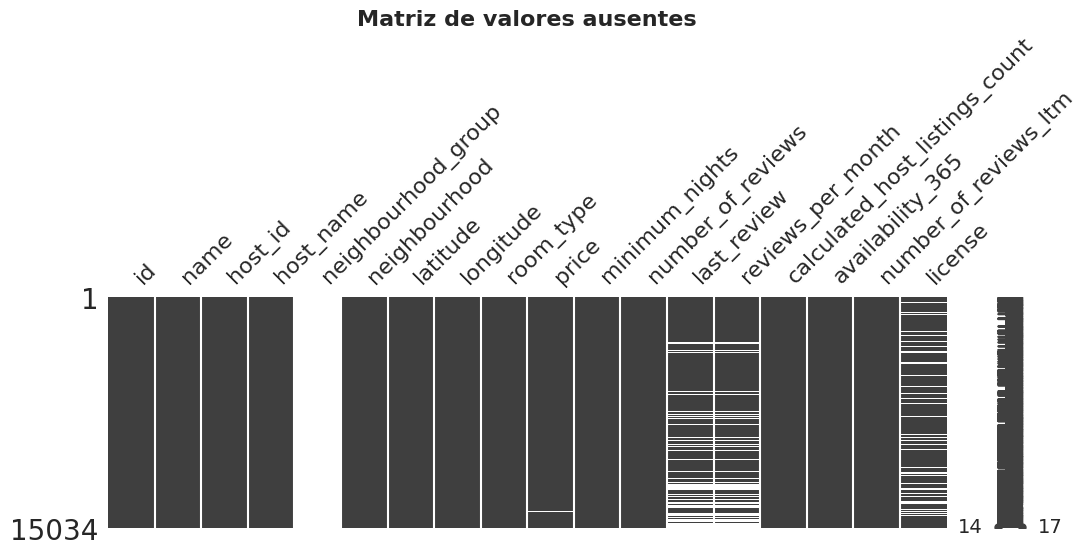

In [16]:
# Matriz com os valores ausentes
# Todas as linhas brancas representa os valores ausentes
import missingno as msno

msno.matrix(df_original,figsize=(12,3))
plt.title('Matriz de valores ausentes',fontsize=16,fontweight='bold')
plt.show()

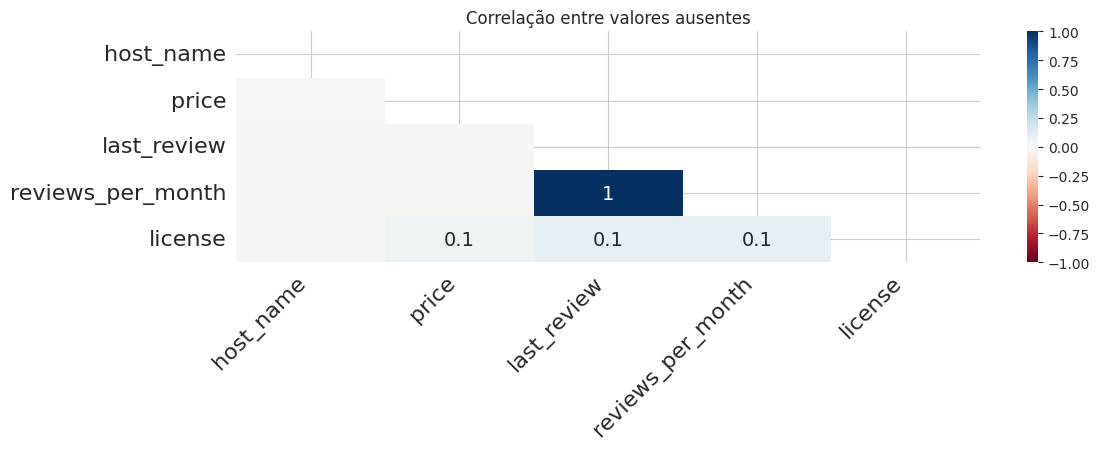

In [17]:
# Correlação dos valores ausentes
# Podemos ver uma alta correlação de valores ausentes entre reviews_per_month e last_review
msno.heatmap(df_original,figsize=(12,3))
plt.title('Correlação entre valores ausentes')
plt.show()

### **2.3 - Qual o tipo de distribuição das variáveis?**

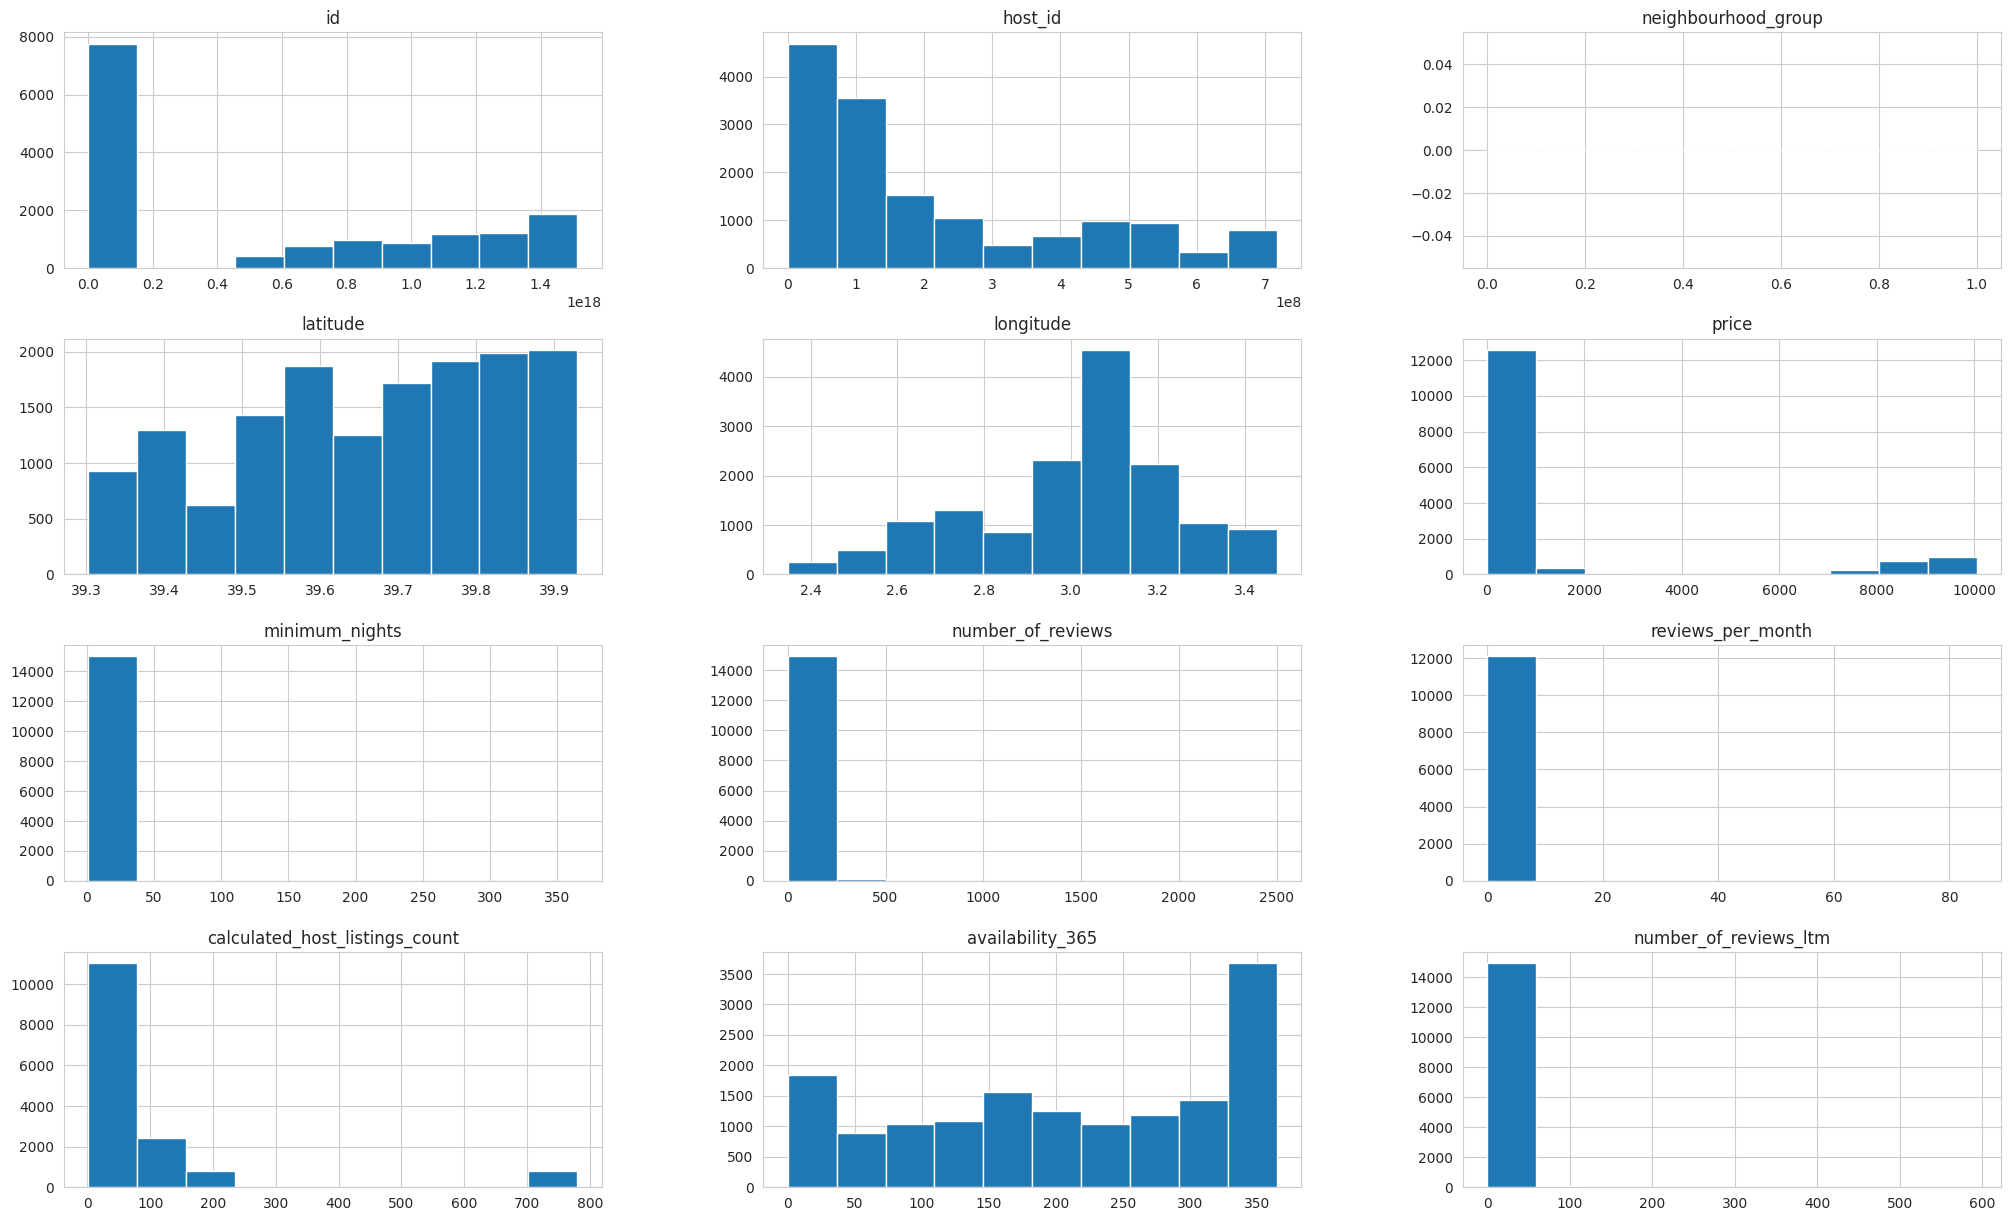

In [18]:
# plotar o histograma das variáveis numéricas
# Nesse cenário podemos ver em qual faixa está a concentração de dados
# Podemos ver a assimetria dos dados e os outliers

df.hist(bins=10, figsize=(25, 15))
plt.show()

### **2.4 - Existem outliers no nosso Dataframe?**

De acordo com a distribuição do histograma, podemos ver que existem outliers e iremos verificar essas colunas para entender melhor os dados.

Abaixo, iremos analisar as colunas abaixo:
- price
- minimum_nights
- number_of_reviews
- reviews_per_month
- calculated_host_listings_count
- availability_365
- number_of_reviews_ltm

In [19]:
df[['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365','number_of_reviews_ltm']].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,15027.00,15034.00,15034.00,12124.00,15034.00,15034.00,15034.00
mean,1512.97,4.12,26.53,0.76,84.05,209.13,6.22
std,3047.83,9.56,56.17,1.51,172.15,119.90,13.41
min,10.00,1.00,0.00,0.01,1.00,0.00,0.00
25%,170.00,1.00,1.00,0.19,2.00,109.00,0.00
50%,275.00,1.00,9.00,0.45,21.00,213.00,2.00
75%,527.00,5.00,30.00,0.93,83.00,327.00,8.00
max,10053.00,365.00,2501.00,84.72,780.00,365.00,593.00


### **2.5 - Análises dos Outliers**

- price <br>
Na coluna price, 75% dos valores estão abaixo de 527 e seu valor máximo é de 10.053 mil euros. <br>
A média é muito maior que a mediana, quase 6 vezes maior, e isso quer dizer que é uma distribuição fortemente assimétrica à direita. <br>

- minimum_nights <br>
Existe um outlier muito forte, visto que a média é muito maior que a mediana demonstrando uma assimetria à direita. <br>
Um detalhe estranho é que 75% dos valores estão abaixo de 5 e o valor máximo é de 365. Então temos um valor de 365 onde a maioria dos valores é igual a 1, isso indica um erro de entrada ou um caso isolado que distorce a média. <br>

- number_of_reviews <br>
A média é muito maior que a mediana e esse indicador quer dizer que existe uma distribuição fortemente assimétrica à direita. <br>
75% das reviews são menores que 30, levando em consideração que a média de disponibilidade dos imóveis são de 26 dias, temos baixa atividade sendo de 1 avaliação por mês. <br>
Possui uma máxima de 2500. <br>
A maioria dos anúncios tem pouca avaliação e anúncios mais antigos/populares concentram muitas reviews. <br>

- reviews_per_month <br>
Mais uma vez, podemos ver a média maior que a mediana o que indica uma distribuição assimétrica à direita e também podemos dizer que existem poucos anúncios muito ativos que puxa a média para cima. Isso reforça que a maioria tem baixa atividade, e poucos são muito ativos. <br>
A baixa atividade vem de 3 evidências combinadas, mediana < 1 review/mês, 75% dos anúncios < 2 reviews/mês e assimetria positiva (poucos muito ativos). <br>

- calculated_host_listings_count <br>
Podemos ver forte assimetria à direita porque a média é maior que a mediana. <br>
A maioria dos hots possui 1 ou 2 anúncios (50% = 2). <br>
Quando vemos o número máximo de 780, podemos inferir que esse número não é normal e representa uma gestão de portfólio, ou seja, um host pode ter mais de 10 anúncios. <br>

- availability_365 <br>
Nesta coluna também podemos ver a forte assimetria à direita, porque a média é maior que a mediana. <br>
75% dos imóveis possuem disponibilidade abaixo de 327, ou seja, estão disponíveis mais da metade do ano. <br>

- number_of_reviews_ltm <br>
Mediana menor que a média segue o padrão de forte assimetria à direita. <br>
A maioria dos imóveis tiveram baixa atividade recente. <br>
Essa é uma boa métrica para medir o desempenho atual.





In [20]:
# Investigando os imóveis mais caros
print("Top 10 imóveis mais caros:")
colunas_investigar = ['price', 'room_type', 'neighbourhood',
                       'minimum_nights', 'number_of_reviews']

# Seleciona apenas as colunas que existem no seu df
cols_existentes = [c for c in colunas_investigar if c in df_original.columns]

top20 = df_original.nlargest(20, 'price')[cols_existentes]
print(top20.to_string())

Top 10 imóveis mais caros:
         price        room_type      neighbourhood  minimum_nights  number_of_reviews
5525  10053.00  Entire home/apt            Alcúdia               1                  3
14648 10036.00  Entire home/apt            Alcúdia               1                  0
15027 10036.00  Entire home/apt           Pollença               1                  0
4015  10032.00  Entire home/apt           Santanyí               1                  4
11748 10031.00  Entire home/apt            Alcúdia               1                  2
11716 10027.00  Entire home/apt           Sa Pobla               1                  5
11955 10026.00  Entire home/apt    Santa Margalida               1                  1
14790 10026.00  Entire home/apt           Santanyí               1                  0
6799  10018.00  Entire home/apt            Alcúdia               1                 22
6800  10018.00  Entire home/apt            Alcúdia               1                 13
10856 10018.00  Entire home

Podemos ver que os valores dos imóveis mais caros são casas ou apartamentos inteiros em bairros nobres de Mallorca e alguns com bastante avaliação, mesmo sendo de luxo.

**OBS:** Meu objetivo com essa análise exploratória é analisar o mercado geral do Airbnb, por esse motivo eu vou realizar o tratamento do outlier utilizando a Winsorização.

In [21]:
# Entender os menores valores para verificar se foi algum erro de digitação.

bottom20 = df_original.nsmallest(30, 'price')[cols_existentes]
print(bottom20.to_string())

       price        room_type               neighbourhood  minimum_nights  number_of_reviews
1878   10.00  Entire home/apt                 Puigpunyent               7                 21
14253  10.00  Entire home/apt                    Sa Pobla              31                  2
14387  19.00     Private room           Palma de Mallorca              30                  0
130    21.00     Private room                    Sa Pobla               1                148
13190  22.00     Private room           Palma de Mallorca              28                  1
5644   25.00     Private room                    Pollença               1                  5
3588   27.00     Private room           Palma de Mallorca              32                 63
10420  27.00     Private room           Palma de Mallorca              30                  1
4717   28.00     Private room                     Manacor               7                 74
5632   28.00     Private room                     Manacor             

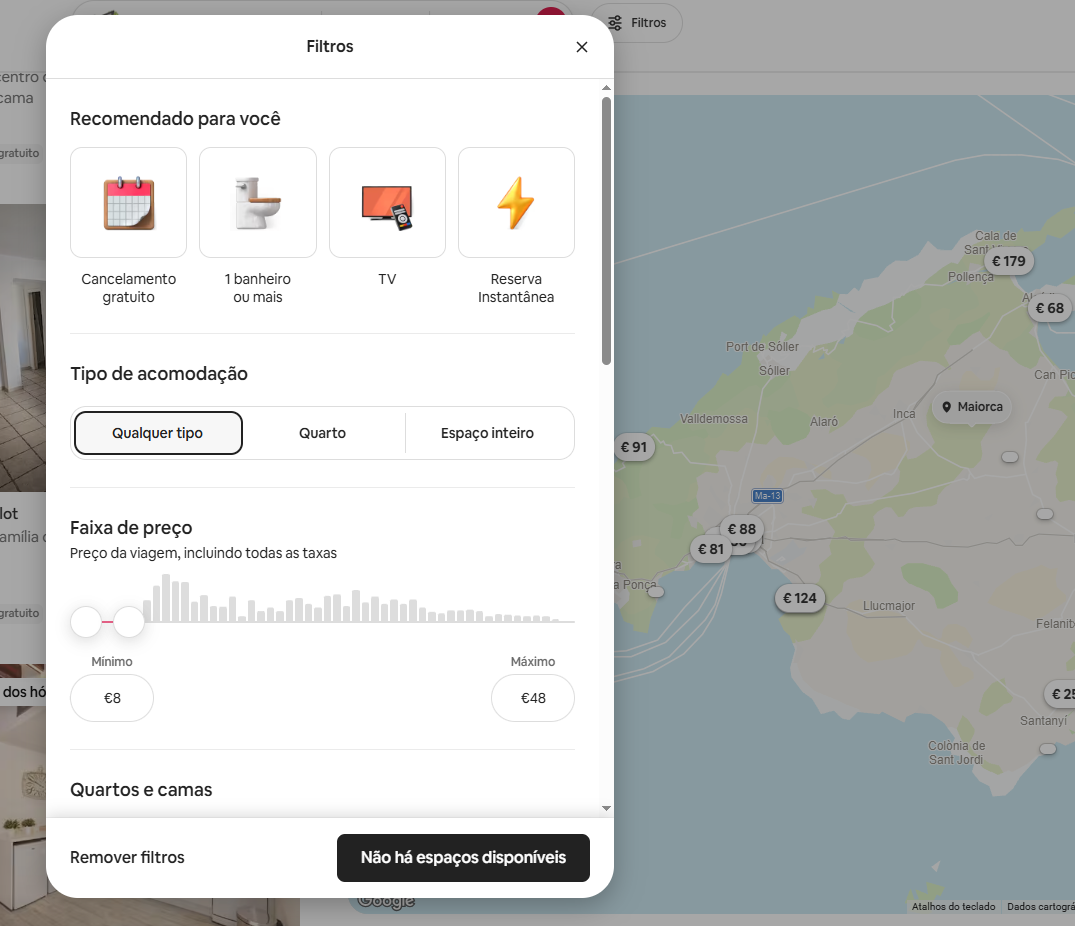

Vimos o valor entre 10 e 63 euros para casa ou apartamento parece ser algum erro de digitação, visto que o menor valor de quarto inteiro é a partir de 65 euros.

#### **2.5.1 - Price**

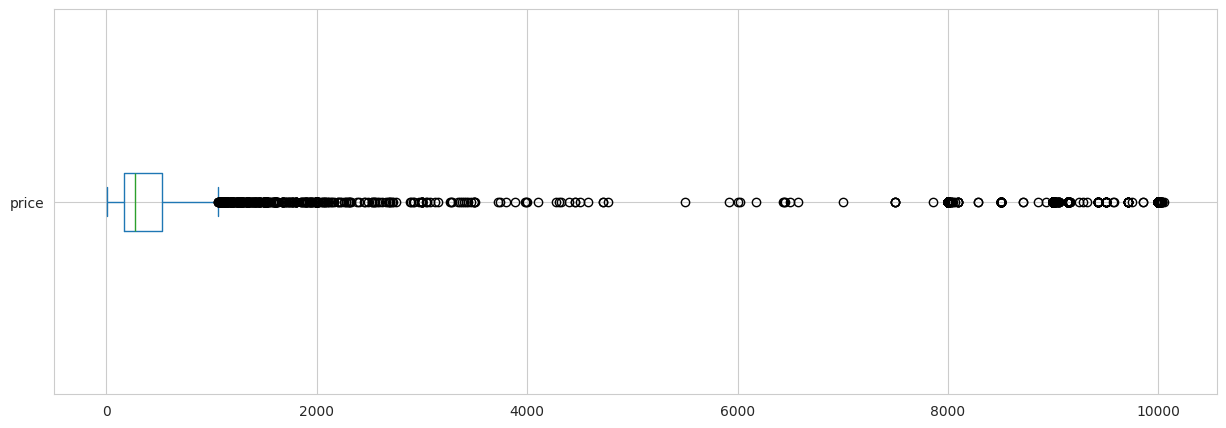

Valores maiores ou iguais a 275: 7548
Valores menores ou iguais a 100: 1073
Percentual em relação ao tamanho do dataframe maiores que 275: 50.2062%
Percentual em relação ao tamanho do dataframe menores que 100: 7.1372%


In [22]:
# Utilizei o valor da mediana para verificar a quantidade e percentual de valores iguais ou maior
df_original.price.plot(kind='box',vert=False,figsize=(15,5))
plt.show()

print(f'Valores maiores ou iguais a 275: {len(df_original[df_original.price >= 275])}')
print(f'Valores menores ou iguais a 100: {len(df_original[df_original.price <= 100])}')
print(f'Percentual em relação ao tamanho do dataframe maiores que 275: {(len(df_original[df_original.price >= 275]) / df.shape[0]):.4%}')
print(f'Percentual em relação ao tamanho do dataframe menores que 100: {(len(df_original[df_original.price <= 100]) / df.shape[0]):.4%}')

In [23]:
# Vimos que os valores menores que 63 euros, pode ser algum erros de digitação e vamos cortar do nosso dataset
df_original = df_original[df_original.price >= 63]

##### **2.5.1.1 - Winsorização Price**

Vamos substituir os valores extremos pelo valor do percentil limite.

In [42]:
print('='* 60)
print(' MAPEAMENTO COMPLETO DOS PREÇOS POR PERCENTIL  ')
print('='* 60)

percentil = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100]

for p in percentil:
  valor = df_original.price.quantile(p/100)
  barra = '█' * int(valor/50)
  print(f'p {p:>5.1f}% -> € {valor:>8.0f} {barra}')

 MAPEAMENTO COMPLETO DOS PREÇOS POR PERCENTIL  
p   5.0% -> €       98 █
p  10.0% -> €      120 ██
p  15.0% -> €      140 ██
p  20.0% -> €      156 ███
p  25.0% -> €      175 ███
p  30.0% -> €      190 ███
p  35.0% -> €      210 ████
p  40.0% -> €      230 ████
p  45.0% -> €      252 █████
p  50.0% -> €      279 █████
p  55.0% -> €      307 ██████
p  60.0% -> €      344 ██████
p  65.0% -> €      390 ███████
p  70.0% -> €      450 █████████
p  75.0% -> €      538 ██████████
p  80.0% -> €      710 ██████████████
p  85.0% -> €     1500 ██████████████████████████████
p  90.0% -> €     9000 ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
p  95.0% -> €     9999 ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
p 1

In [25]:
print(f'Imóveis abaixo de 1500: {(df_original.price <= 1500).sum()}')
print(f'Imóveis acima de 1500: {(df_original.price > 1500).sum()}')
print(f'Imóveis acima de 2500: {(df_original.price > 2500).sum()}')
print(f'Imóveis acima de 3500: {(df_original.price > 3500).sum()}')
print(f'Imóveis acima de 5500: {(df_original.price > 5500).sum()}')
print(f'Imóveis acima de 7500: {(df_original.price > 7500).sum()}')
print(f'Imóveis acima de 9500: {(df_original.price > 9500).sum()}')

Imóveis abaixo de 1500: 12597
Imóveis acima de 1500: 2214
Imóveis acima de 2500: 2040
Imóveis acima de 3500: 1994
Imóveis acima de 5500: 1973
Imóveis acima de 7500: 1959
Imóveis acima de 9500: 814


**OBS:** Podemos ver que mais de 85% dos valores são menores ou iguais a 1500, ou seja, os valores acima de 2000 pode distorcer minha análise e por isso vamos aplicar a Winsorização.

In [26]:
# Não quero deletar os dados do meu dataframe porque posso perder linhas com valores importantes.
# O preço mais alto é de 10 mil e isso pode indicar um imóvel de luxo,
# porém o valor mais baixo de 10 até 63 reais pode ser um erro de digitação.

percentil_min = df_original.price.quantile(0.10)
percentil_max = df_original.price.quantile(0.85)

print(f'Limite inferior - {percentil_min}')
print(f'Limite superior - {percentil_max}')

df_original['price_winsorizado'] = df_original.price.clip(lower=percentil_min,upper=percentil_max)
df_original.head(5)


Limite inferior - 120.0
Limite superior - 1500.0


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,price_winsorizado
0,69998,WFH loft… Hideaway xperience in Palma old town,353156,Lor,NaN,Palma de Mallorca,39.57,2.65,Entire home/apt,164.00,32,266,2025-06-27,1.60,2,309,2,NaN,164.00
1,106833,Villa with a big pool in Mallorca,551974,Xisco,NaN,Sant Llorenç des Cardassar,39.61,3.30,Entire home/apt,200.00,5,32,2025-09-02,0.20,1,5,5,ESFCTU00A00702300107013400000000000000000000ET...,200.00
2,159218,Farmhouse in Nature -ETV-3025,763897,Gabriel,NaN,Selva,39.79,2.91,Entire home/apt,160.00,4,407,2025-09-20,2.38,2,308,28,ESFCTU00000702200009178200000000000000000000ET...,160.00
3,166820,Guest House with Great sea views - Principal Room,794829,Toni,NaN,Banyalbufar,39.68,2.50,Private room,75.00,1,359,2025-08-31,2.09,3,250,45,VT 1719,120.00
4,210156,Room Berna ETV/7989,1036132,Toni,NaN,Alcúdia,39.83,3.11,Private room,92.00,7,132,2025-09-19,0.83,3,0,6,ETV/7989,120.00


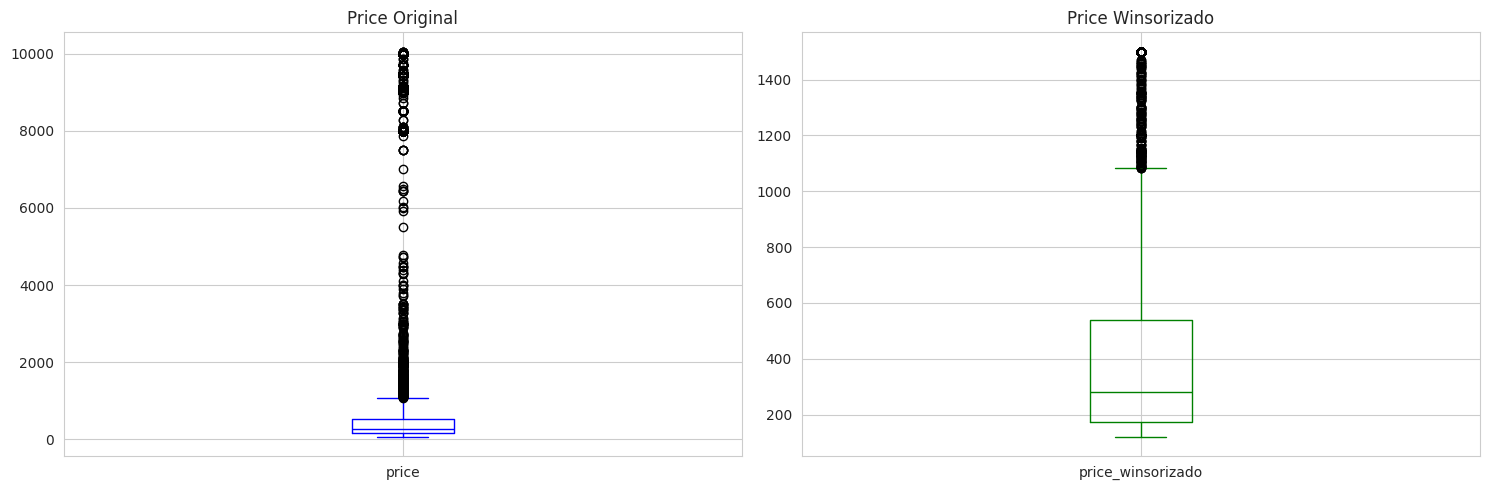

In [27]:
fig,axes = plt.subplots(1,2,figsize=(15,5))

df_original.price.plot(kind='box', ax=axes[0], title='Price Original', color='blue')

df_original.price_winsorizado.plot(kind='box', ax=axes[1], title='Price Winsorizado', color='green')

plt.tight_layout()
plt.show()

In [28]:
df_original.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,price_winsorizado
count,14811.00,14811.00,0.00,14811.00,14811.00,14811.00,14811.00,14811.00,11936.00,14811.00,14811.00,14811.00,14811.00
mean,526241519005879104.00,208397848.62,NaN,39.66,3.02,1534.29,4.02,26.33,0.73,85.22,209.44,6.08,487.74
std,583864638004946048.00,203652732.56,NaN,0.18,0.23,3064.82,9.42,55.92,1.28,173.16,119.94,12.70,469.73
min,69998.00,18651.00,NaN,39.30,2.35,63.00,1.00,0.00,0.01,1.00,0.00,0.00,120.00
25%,27994626.50,49644663.50,NaN,39.53,2.90,175.00,1.00,1.00,0.19,2.00,109.00,0.00,175.00
50%,52764553.00,122491844.00,NaN,39.69,3.06,279.00,1.00,8.00,0.44,22.00,213.00,2.00,279.00
75%,1116441362739559808.00,347448179.00,NaN,39.82,3.15,538.00,5.00,30.00,0.91,85.00,327.00,8.00,538.00
max,1513880348430843648.00,717746061.00,NaN,39.93,3.47,10053.00,365.00,2501.00,47.82,780.00,365.00,593.00,1500.00


##### **2.5.1.2 - Minimum Nights**

In [29]:
df_original[df_original.minimum_nights > 31][['neighbourhood','room_type','price','minimum_nights','number_of_reviews','calculated_host_listings_count']].sort_values('minimum_nights',ascending=False).head(20)

,neighbourhood,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count
2154,Palma de Mallorca,Entire home/apt,135.00,365,3,1
682,Santa Margalida,Entire home/apt,300.00,365,24,1
4497,Sant Llorenç des Cardassar,Entire home/apt,175.00,365,0,1
12625,Calvià,Entire home/apt,1242.00,365,0,5
11710,Palma de Mallorca,Entire home/apt,162.00,265,0,1
14525,Santa Margalida,Entire home/apt,90.00,211,0,2
9513,Alcúdia,Entire home/apt,138.00,183,0,1
7371,Pollença,Entire home/apt,65.00,180,0,2
10102,Capdepera,Entire home/apt,490.00,180,0,1
447,Ses Salines,Entire home/apt,190.00,150,9,2


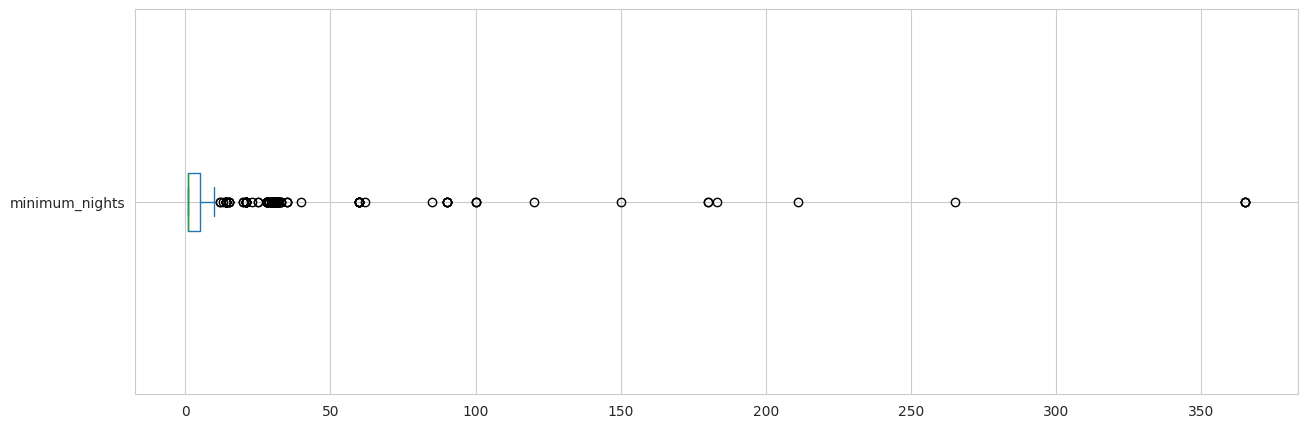

Valores maiores ou iguais a 7: 2350
Percentual em relação ao tamanho do dataframe: 15.6312%


In [30]:
df_original.minimum_nights.plot(kind='box',vert=False,figsize=(15,5))
plt.show()

print(f'Valores maiores ou iguais a 7: {len(df[df.minimum_nights >= 7])}')
print(f'Percentual em relação ao tamanho do dataframe: {(len(df[df.minimum_nights >= 7]) / df.shape[0]):.4%}')

In [31]:
print('='* 60)
print(' MAPEAMENTO COMPLETO MINIMUM NIGHTS  ')
print('='* 60)

for p in percentil:
  valor = df_original.minimum_nights.quantile(p/100)
  barra = '█' * int(valor/5)
  print(f'p {p:>5.1f}% -> € {valor:>8.0f} {barra}')

 MAPEAMENTO COMPLETO MINIMUM NIGHTS  
p   5.0% -> €        1 
p  10.0% -> €        1 
p  15.0% -> €        1 
p  20.0% -> €        1 
p  25.0% -> €        1 
p  30.0% -> €        1 
p  35.0% -> €        1 
p  40.0% -> €        1 
p  45.0% -> €        1 
p  50.0% -> €        1 
p  55.0% -> €        2 
p  60.0% -> €        3 
p  65.0% -> €        4 
p  70.0% -> €        5 █
p  75.0% -> €        5 █
p  80.0% -> €        5 █
p  85.0% -> €        7 █
p  90.0% -> €        7 █
p  95.0% -> €        7 █
p 100.0% -> €      365 █████████████████████████████████████████████████████████████████████████


**OBS:** Como a média é muito maior que a mediana também vamos aplicar a Winsorização para manter os as linhas ao invés de deletar.

In [32]:
percentil_min = df_original.minimum_nights.quantile(0.10)
percentil_max = df_original.minimum_nights.quantile(0.90)

print(f'Limite inferior - {percentil_min}')
print(f'Limite superior - {percentil_max}')

df_original['minimum_nights_winsorizado'] = df_original.minimum_nights.clip(lower=percentil_min,upper=percentil_max)
df_original.head(5)

Limite inferior - 1.0
Limite superior - 7.0


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,price_winsorizado,minimum_nights_winsorizado
0,69998,WFH loft… Hideaway xperience in Palma old town,353156,Lor,NaN,Palma de Mallorca,39.57,2.65,Entire home/apt,164.00,32,266,2025-06-27,1.60,2,309,2,NaN,164.00,7
1,106833,Villa with a big pool in Mallorca,551974,Xisco,NaN,Sant Llorenç des Cardassar,39.61,3.30,Entire home/apt,200.00,5,32,2025-09-02,0.20,1,5,5,ESFCTU00A00702300107013400000000000000000000ET...,200.00,5
2,159218,Farmhouse in Nature -ETV-3025,763897,Gabriel,NaN,Selva,39.79,2.91,Entire home/apt,160.00,4,407,2025-09-20,2.38,2,308,28,ESFCTU00000702200009178200000000000000000000ET...,160.00,4
3,166820,Guest House with Great sea views - Principal Room,794829,Toni,NaN,Banyalbufar,39.68,2.50,Private room,75.00,1,359,2025-08-31,2.09,3,250,45,VT 1719,120.00,1
4,210156,Room Berna ETV/7989,1036132,Toni,NaN,Alcúdia,39.83,3.11,Private room,92.00,7,132,2025-09-19,0.83,3,0,6,ETV/7989,120.00,7


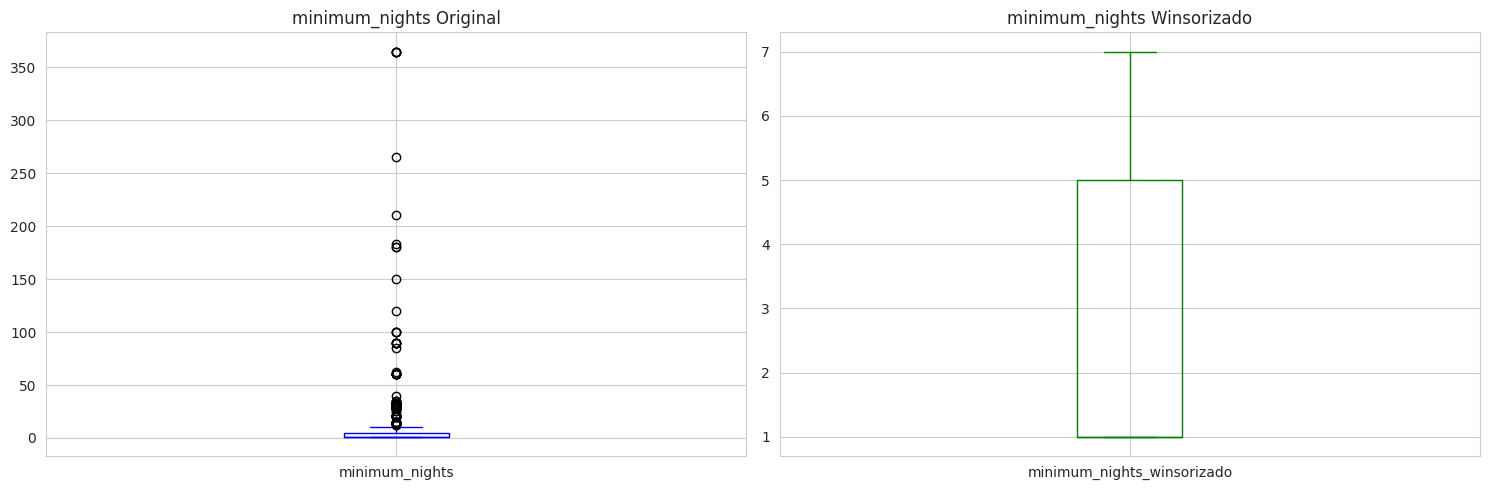

In [33]:
fig,axes = plt.subplots(1,2,figsize=(15,5))

df_original.minimum_nights.plot(kind='box', ax=axes[0], title='minimum_nights Original', color='blue')

df_original.minimum_nights_winsorizado.plot(kind='box', ax=axes[1], title='minimum_nights Winsorizado', color='green')

plt.tight_layout()
plt.show()

In [34]:
df_original.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,price_winsorizado,minimum_nights_winsorizado
count,14811.00,14811.00,0.00,14811.00,14811.00,14811.00,14811.00,14811.00,11936.00,14811.00,14811.00,14811.00,14811.00,14811.00
mean,526241519005879104.00,208397848.62,NaN,39.66,3.02,1534.29,4.02,26.33,0.73,85.22,209.44,6.08,487.74,2.93
std,583864638004946048.00,203652732.56,NaN,0.18,0.23,3064.82,9.42,55.92,1.28,173.16,119.94,12.70,469.73,2.33
min,69998.00,18651.00,NaN,39.30,2.35,63.00,1.00,0.00,0.01,1.00,0.00,0.00,120.00,1.00
25%,27994626.50,49644663.50,NaN,39.53,2.90,175.00,1.00,1.00,0.19,2.00,109.00,0.00,175.00,1.00
50%,52764553.00,122491844.00,NaN,39.69,3.06,279.00,1.00,8.00,0.44,22.00,213.00,2.00,279.00,1.00
75%,1116441362739559808.00,347448179.00,NaN,39.82,3.15,538.00,5.00,30.00,0.91,85.00,327.00,8.00,538.00,5.00
max,1513880348430843648.00,717746061.00,NaN,39.93,3.47,10053.00,365.00,2501.00,47.82,780.00,365.00,593.00,1500.00,7.00


##### **2.5.1.3 - Number of Reviews**

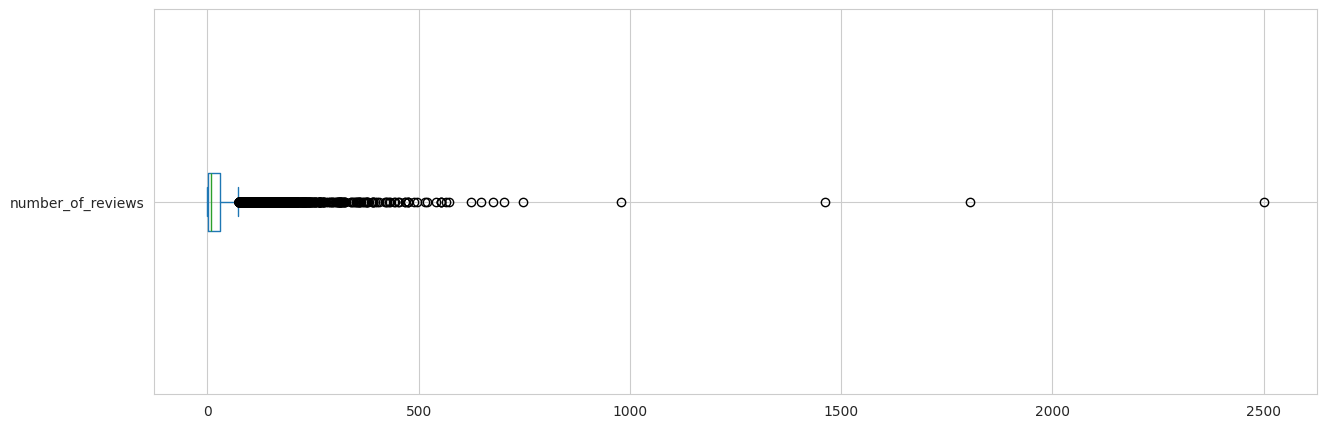

Valores maiores ou iguais a 100: 905
Percentual em relação ao tamanho do dataframe: 6.0197%


In [35]:
df_original.number_of_reviews.plot(kind='box',vert=False,figsize=(15,5))
plt.show()

print(f'Valores maiores ou iguais a 100: {len(df[df.number_of_reviews >= 100])}')
print(f'Percentual em relação ao tamanho do dataframe: {(len(df[df.number_of_reviews >= 100]) / df.shape[0]):.4%}')

In [36]:
print('='* 60)
print(' MAPEAMENTO COMPLETO NUMBER OF REVIEWS  ')
print('='* 60)

for p in percentil:
  valor = df_original.number_of_reviews.quantile(p/100)
  barra = '█' * int(valor/5)
  print(f'p {p:>5.1f}% -> € {valor:>8.0f} {barra}')

 MAPEAMENTO COMPLETO NUMBER OF REVIEWS  
p   5.0% -> €        0 
p  10.0% -> €        0 
p  15.0% -> €        0 
p  20.0% -> €        1 
p  25.0% -> €        1 
p  30.0% -> €        2 
p  35.0% -> €        3 
p  40.0% -> €        4 
p  45.0% -> €        6 █
p  50.0% -> €        8 █
p  55.0% -> €       11 ██
p  60.0% -> €       15 ███
p  65.0% -> €       19 ███
p  70.0% -> €       23 ████
p  75.0% -> €       30 ██████
p  80.0% -> €       38 ███████
p  85.0% -> €       51 ██████████
p  90.0% -> €       69 █████████████
p  95.0% -> €      110 ██████████████████████
p 100.0% -> €     2501 ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [43]:
percentil_min = df_original.number_of_reviews.quantile(0.45)
percentil_max = df_original.number_of_reviews.quantile(0.90)

print(f'Limite inferior - {percentil_min}')
print(f'Limite superior - {percentil_max}')

df_original['number_of_reviews_winsorizado'] = df_original.number_of_reviews.clip(lower=percentil_min,upper=percentil_max)
df_original.head(5)

Limite inferior - 6.0
Limite superior - 69.0


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,price_winsorizado,minimum_nights_winsorizado,number_of_reviews_winsorizado
0,69998,WFH loft… Hideaway xperience in Palma old town,353156,Lor,NaN,Palma de Mallorca,39.57,2.65,Entire home/apt,164.00,32,266,2025-06-27,1.60,2,309,2,NaN,164.00,7,69
1,106833,Villa with a big pool in Mallorca,551974,Xisco,NaN,Sant Llorenç des Cardassar,39.61,3.30,Entire home/apt,200.00,5,32,2025-09-02,0.20,1,5,5,ESFCTU00A00702300107013400000000000000000000ET...,200.00,5,32
2,159218,Farmhouse in Nature -ETV-3025,763897,Gabriel,NaN,Selva,39.79,2.91,Entire home/apt,160.00,4,407,2025-09-20,2.38,2,308,28,ESFCTU00000702200009178200000000000000000000ET...,160.00,4,69
3,166820,Guest House with Great sea views - Principal Room,794829,Toni,NaN,Banyalbufar,39.68,2.50,Private room,75.00,1,359,2025-08-31,2.09,3,250,45,VT 1719,120.00,1,69
4,210156,Room Berna ETV/7989,1036132,Toni,NaN,Alcúdia,39.83,3.11,Private room,92.00,7,132,2025-09-19,0.83,3,0,6,ETV/7989,120.00,7,69


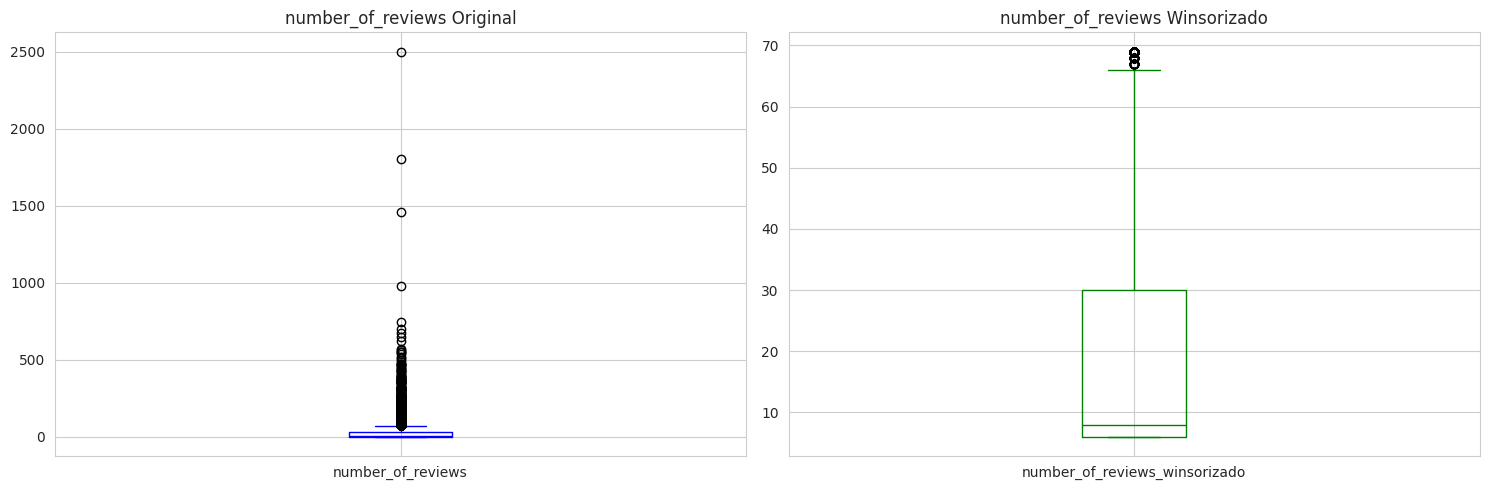

In [44]:
fig,axes = plt.subplots(1,2,figsize=(15,5))

df_original.number_of_reviews.plot(kind='box', ax=axes[0], title='number_of_reviews Original', color='blue')

df_original.number_of_reviews_winsorizado.plot(kind='box', ax=axes[1], title='number_of_reviews Winsorizado', color='green')

plt.tight_layout()
plt.show()

In [45]:
df_original.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,price_winsorizado,minimum_nights_winsorizado,number_of_reviews_winsorizado
count,14811.00,14811.00,0.00,14811.00,14811.00,14811.00,14811.00,14811.00,11936.00,14811.00,14811.00,14811.00,14811.00,14811.00,14811.00
mean,526241519005879104.00,208397848.62,NaN,39.66,3.02,1534.29,4.02,26.33,0.73,85.22,209.44,6.08,487.74,2.93,21.15
std,583864638004946048.00,203652732.56,NaN,0.18,0.23,3064.82,9.42,55.92,1.28,173.16,119.94,12.70,469.73,2.33,21.54
min,69998.00,18651.00,NaN,39.30,2.35,63.00,1.00,0.00,0.01,1.00,0.00,0.00,120.00,1.00,6.00
25%,27994626.50,49644663.50,NaN,39.53,2.90,175.00,1.00,1.00,0.19,2.00,109.00,0.00,175.00,1.00,6.00
50%,52764553.00,122491844.00,NaN,39.69,3.06,279.00,1.00,8.00,0.44,22.00,213.00,2.00,279.00,1.00,8.00
75%,1116441362739559808.00,347448179.00,NaN,39.82,3.15,538.00,5.00,30.00,0.91,85.00,327.00,8.00,538.00,5.00,30.00
max,1513880348430843648.00,717746061.00,NaN,39.93,3.47,10053.00,365.00,2501.00,47.82,780.00,365.00,593.00,1500.00,7.00,69.00


##### **2.5.1.4 - Calculated Host Listings Count**

In [46]:
print('='* 60)
print(' MAPEAMENTO COMPLETO CALCULATED HOST LISTING COUNT  ')
print('='* 60)

for p in percentil:
  valor = df_original.calculated_host_listings_count.quantile(p/100)
  barra = '█' * int(valor/5)
  print(f'p {p:>5.1f}% -> € {valor:>8.0f} {barra}')

 MAPEAMENTO COMPLETO CALCULATED HOST LISTING COUNT  
p   5.0% -> €        1 
p  10.0% -> €        1 
p  15.0% -> €        1 
p  20.0% -> €        2 
p  25.0% -> €        2 
p  30.0% -> €        3 
p  35.0% -> €        5 █
p  40.0% -> €        9 █
p  45.0% -> €       13 ██
p  50.0% -> €       22 ████
p  55.0% -> €       34 ██████
p  60.0% -> €       50 ██████████
p  65.0% -> €       65 █████████████
p  70.0% -> €       74 ██████████████
p  75.0% -> €       85 █████████████████
p  80.0% -> €      108 █████████████████████
p  85.0% -> €      137 ███████████████████████████
p  90.0% -> €      168 █████████████████████████████████
p  95.0% -> €      780 ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
p 100.0% -> €      780 ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████


In [47]:
percentil_min = df_original.calculated_host_listings_count.quantile(0.35)
percentil_max = df_original.calculated_host_listings_count.quantile(0.90)

print(f'Limite inferior - {percentil_min}')
print(f'Limite superior - {percentil_max}')

df_original['calculated_host_listings_count_winsorizado'] = df_original.calculated_host_listings_count.clip(lower=percentil_min,upper=percentil_max)
df_original.head(5)

Limite inferior - 5.0
Limite superior - 168.0


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,price_winsorizado,minimum_nights_winsorizado,number_of_reviews_winsorizado,calculated_host_listings_count_winsorizado
0,69998,WFH loft… Hideaway xperience in Palma old town,353156,Lor,NaN,Palma de Mallorca,39.57,2.65,Entire home/apt,164.00,32,266,2025-06-27,1.60,2,309,2,NaN,164.00,7,69,5
1,106833,Villa with a big pool in Mallorca,551974,Xisco,NaN,Sant Llorenç des Cardassar,39.61,3.30,Entire home/apt,200.00,5,32,2025-09-02,0.20,1,5,5,ESFCTU00A00702300107013400000000000000000000ET...,200.00,5,32,5
2,159218,Farmhouse in Nature -ETV-3025,763897,Gabriel,NaN,Selva,39.79,2.91,Entire home/apt,160.00,4,407,2025-09-20,2.38,2,308,28,ESFCTU00000702200009178200000000000000000000ET...,160.00,4,69,5
3,166820,Guest House with Great sea views - Principal Room,794829,Toni,NaN,Banyalbufar,39.68,2.50,Private room,75.00,1,359,2025-08-31,2.09,3,250,45,VT 1719,120.00,1,69,5
4,210156,Room Berna ETV/7989,1036132,Toni,NaN,Alcúdia,39.83,3.11,Private room,92.00,7,132,2025-09-19,0.83,3,0,6,ETV/7989,120.00,7,69,5


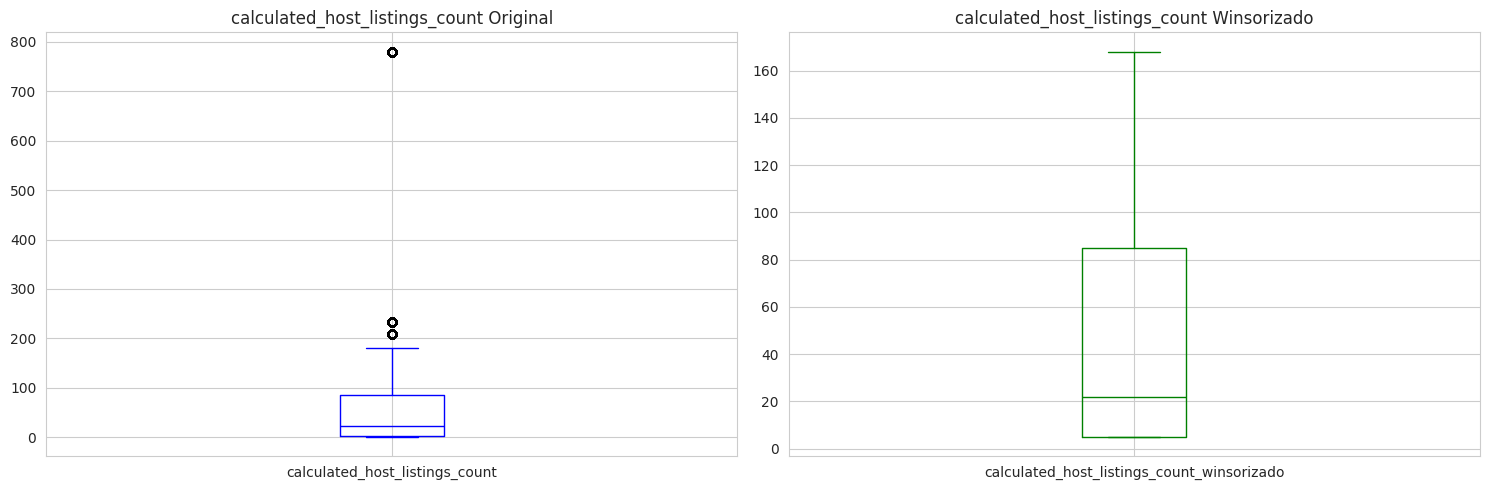

In [48]:
fig,axes = plt.subplots(1,2,figsize=(15,5))

df_original.calculated_host_listings_count.plot(kind='box', ax=axes[0], title='calculated_host_listings_count Original', color='blue')

df_original.calculated_host_listings_count_winsorizado.plot(kind='box', ax=axes[1], title='calculated_host_listings_count Winsorizado', color='green')

plt.tight_layout()
plt.show()

In [49]:
df_original.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,price_winsorizado,minimum_nights_winsorizado,number_of_reviews_winsorizado,calculated_host_listings_count_winsorizado
count,14811.00,14811.00,0.00,14811.00,14811.00,14811.00,14811.00,14811.00,11936.00,14811.00,14811.00,14811.00,14811.00,14811.00,14811.00,14811.00
mean,526241519005879104.00,208397848.62,NaN,39.66,3.02,1534.29,4.02,26.33,0.73,85.22,209.44,6.08,487.74,2.93,21.15,52.31
std,583864638004946048.00,203652732.56,NaN,0.18,0.23,3064.82,9.42,55.92,1.28,173.16,119.94,12.70,469.73,2.33,21.54,57.19
min,69998.00,18651.00,NaN,39.30,2.35,63.00,1.00,0.00,0.01,1.00,0.00,0.00,120.00,1.00,6.00,5.00
25%,27994626.50,49644663.50,NaN,39.53,2.90,175.00,1.00,1.00,0.19,2.00,109.00,0.00,175.00,1.00,6.00,5.00
50%,52764553.00,122491844.00,NaN,39.69,3.06,279.00,1.00,8.00,0.44,22.00,213.00,2.00,279.00,1.00,8.00,22.00
75%,1116441362739559808.00,347448179.00,NaN,39.82,3.15,538.00,5.00,30.00,0.91,85.00,327.00,8.00,538.00,5.00,30.00,85.00
max,1513880348430843648.00,717746061.00,NaN,39.93,3.47,10053.00,365.00,2501.00,47.82,780.00,365.00,593.00,1500.00,7.00,69.00,168.00


### **2.6 - Visualização Após Tratamento dos Outliers**

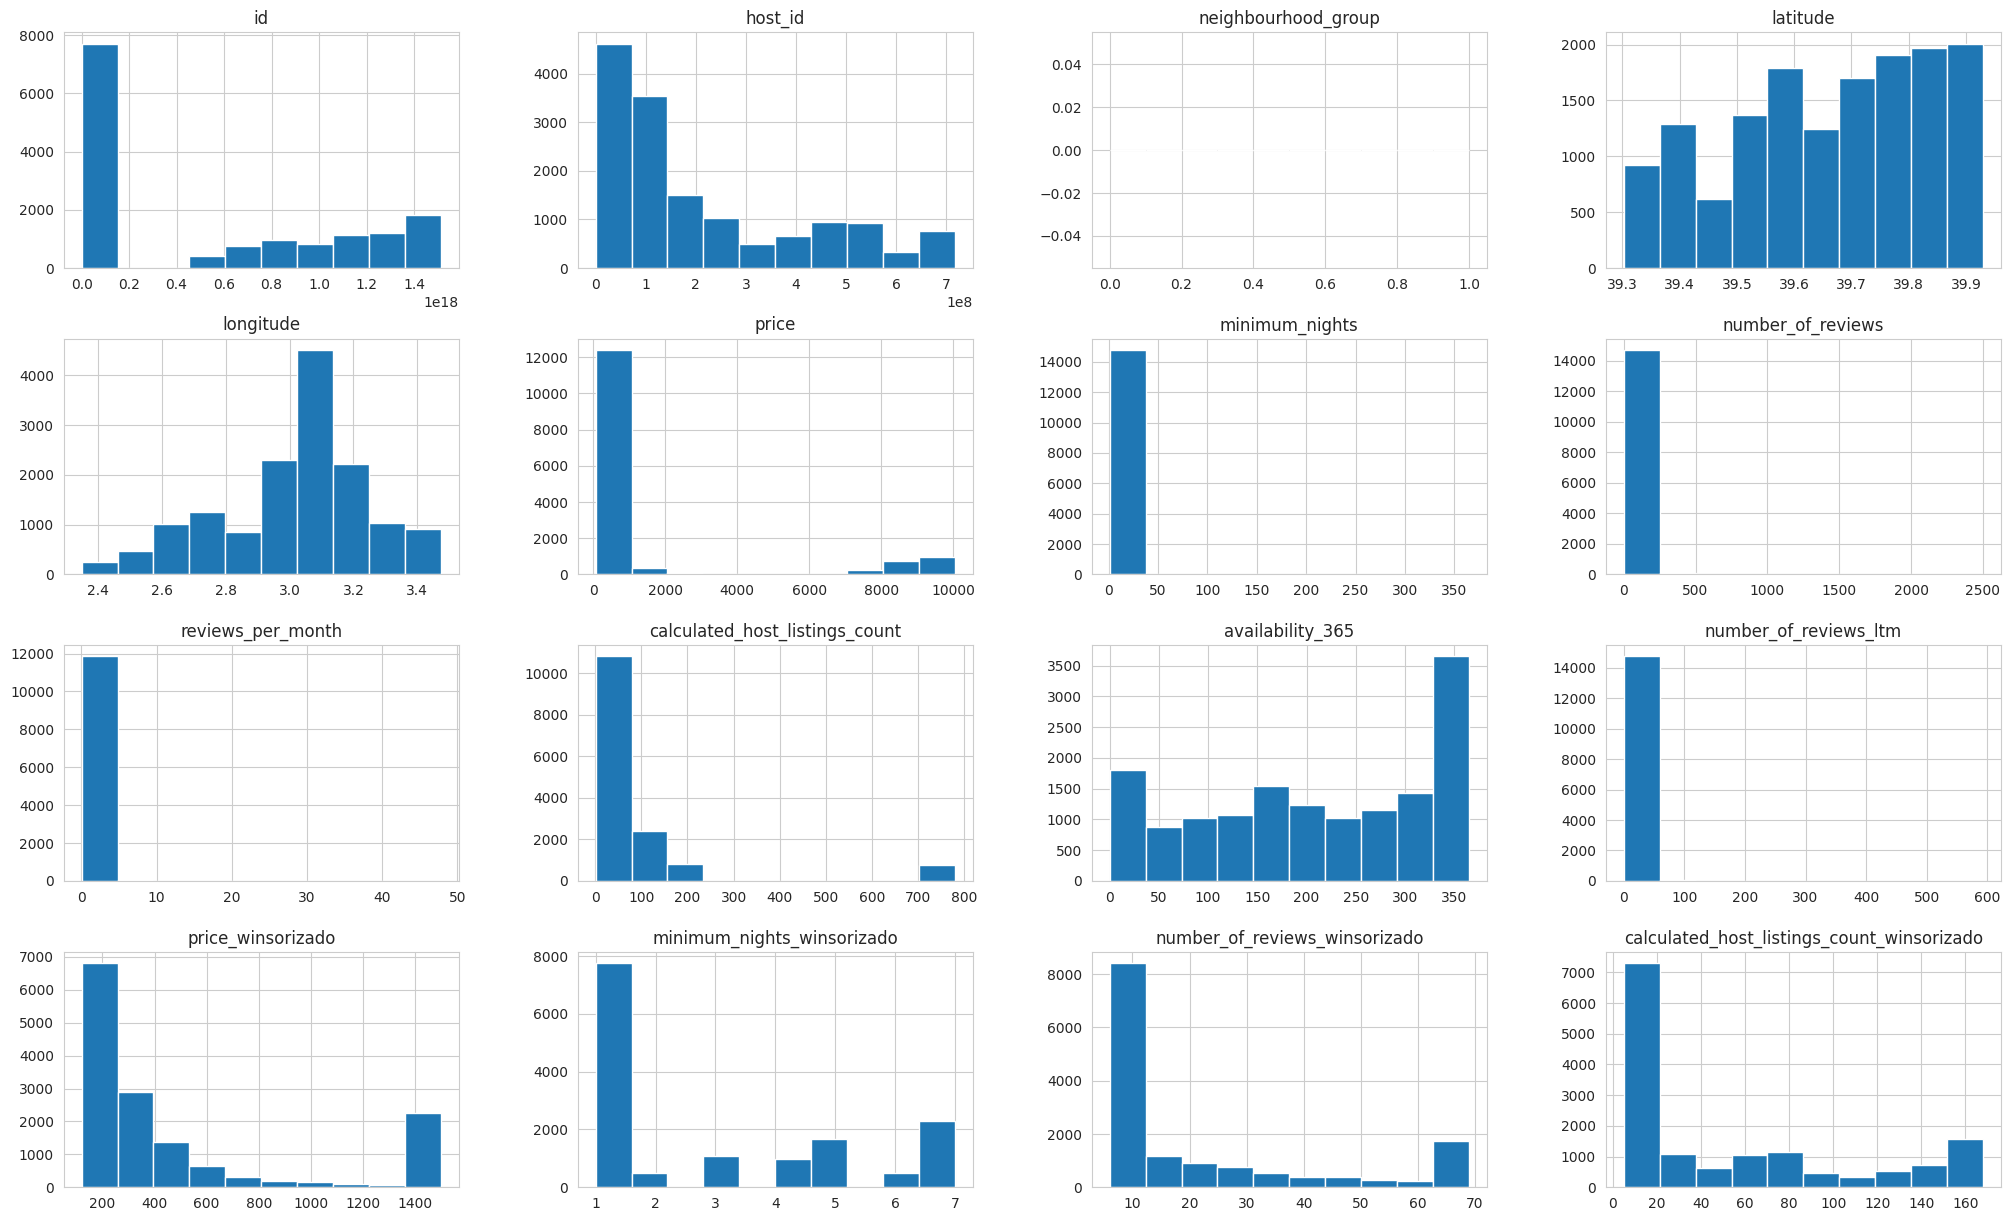

In [50]:
df_clean = df_original.copy()
df_clean.hist(bins=10, figsize=(25, 15))
plt.show()

### **2.7 - Qual a correlação existente entre as variáveis**

A correlação serve para identificar relações entre variáveis numéricas, como:<br>
- Dependência linear
- Redundância de variáveis
- Pistas para hipóteses
- Direcionamento para modelagem

In [51]:
corr = df_clean[['price_winsorizado','minimum_nights_winsorizado','number_of_reviews_winsorizado','reviews_per_month','calculated_host_listings_count_winsorizado','availability_365','number_of_reviews_ltm']].corr()
display(corr)

,price_winsorizado,minimum_nights_winsorizado,number_of_reviews_winsorizado,reviews_per_month,calculated_host_listings_count_winsorizado,availability_365,number_of_reviews_ltm
price_winsorizado,1.00,-0.24,-0.28,-0.15,0.19,0.34,-0.18
minimum_nights_winsorizado,-0.24,1.00,0.18,-0.03,-0.35,-0.12,0.02
number_of_reviews_winsorizado,-0.28,0.18,1.00,0.36,-0.32,-0.03,0.54
reviews_per_month,-0.15,-0.03,0.36,1.00,-0.20,0.03,0.86
calculated_host_listings_count_winsorizado,0.19,-0.35,-0.32,-0.20,1.00,-0.04,-0.20
availability_365,0.34,-0.12,-0.03,0.03,-0.04,1.00,0.01
number_of_reviews_ltm,-0.18,0.02,0.54,0.86,-0.20,0.01,1.00


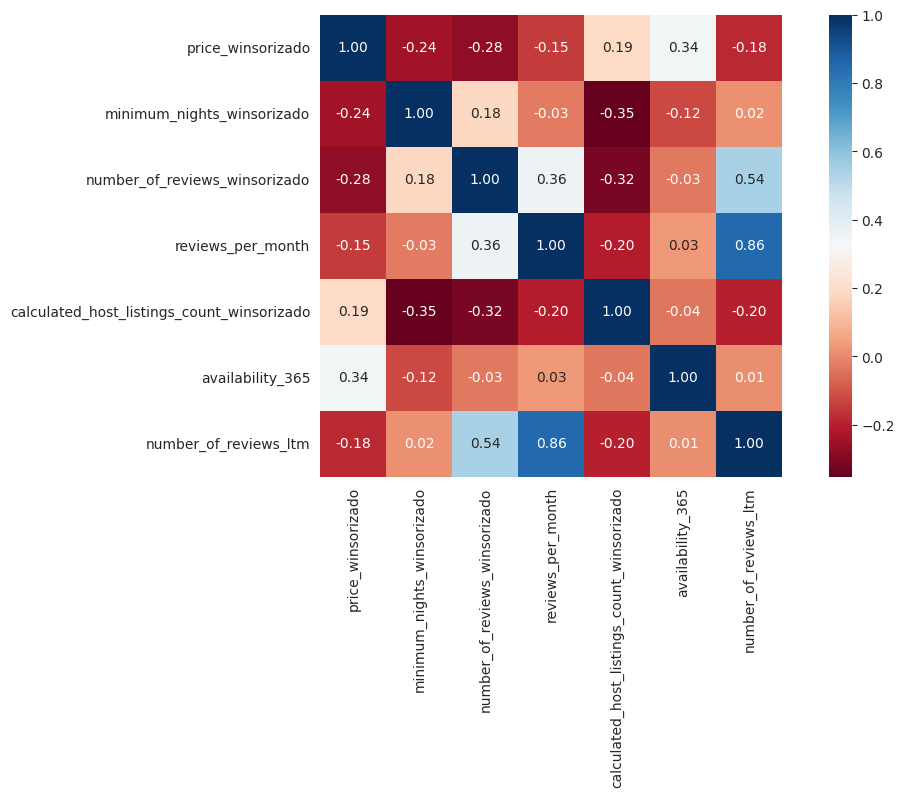

In [52]:
sns.heatmap(corr,cmap='RdBu',fmt='.2f',square=True,linecolor='white',annot=True)
plt.show()

**Obs:**
Na correlação acima, podemos ver uma forte ligação entre a coluna number_of_reviews_ltm e number_of_reviews, number_of_reviews_ltm e review_per_month.

### **2.8 - Qual o tipo de imóvel mais alugado?**

In [53]:
df_clean.room_type.value_counts()

,count
room_type,
Entire home/apt,13975
Private room,793
Hotel room,40
Shared room,3


In [54]:
# porcentagem de cada tipo de imóvel disponível
df_clean.room_type.value_counts() / df_clean.shape[0] * 100

,count
room_type,
Entire home/apt,94.36
Private room,5.35
Hotel room,0.27
Shared room,0.02


### **2.9 - Quais as localidades mais caras de Mallorca?**

In [55]:
df_clean.groupby('neighbourhood')['price'].max().sort_values(ascending=False)[:25]

,price
neighbourhood,
Alcúdia,10053.00
Pollença,10036.00
Santanyí,10032.00
Sa Pobla,10027.00
Santa Margalida,10026.00
Artà,10016.00
Sencelles,10015.00
Inca,10013.00
Palma de Mallorca,10011.00


In [56]:
# Quantidade de imóveis no bairro Alcúdia
print(f'Quantidade de imóveis no bairro Alcúdia - {df_clean[df_clean.neighbourhood == 'Alcúdia'].shape[0]}')

# Quantidade de imóveis no bairro Pollença
print(f'Quantidade de imóveis no bairro Pollença - {df_clean[df_clean.neighbourhood == 'Pollença'].shape[0]}')

# Quantidade de imóveis no bairro Santanyí
print(f'Quantidade de imóveis no bairro Santanyí - {df_clean[df_clean.neighbourhood == 'Santanyí'].shape[0]}')

Quantidade de imóveis no bairro Alcúdia - 1446
Quantidade de imóveis no bairro Pollença - 2352
Quantidade de imóveis no bairro Santanyí - 979


In [57]:
# Vamos mostrar o valor mais barato de Mallorca agrupado por bairro

df_clean.groupby('neighbourhood')['price'].min().sort_values(ascending=True)[:25]

,price
neighbourhood,
Algaida,63.00
Montuïri,63.00
Manacor,63.00
Palma de Mallorca,63.00
Sa Pobla,64.00
Alcúdia,64.00
Capdepera,65.00
Felanitx,65.00
Llucmajor,65.00


# **3 - Cruzamento das Variáveis Categóricas e Numéricas**

## 3.1 - Qual categoria tem maior preço médio?

In [70]:
# Aqui estamos cruzando as variáveis categóricas com as numéricas
price = df_clean.groupby('room_type')['price'].agg(
                                                  media = 'mean',
                                                  mediana = 'median',
                                                  minimo = 'min',
                                                  maximo = 'max',
                                                  contagem = 'count'
                                                  ).round(2).sort_values(by=['room_type','media'],ascending=[True,False])
print('####### Preço médio por tipo de quarto #######')
price.head()

####### Preço médio por tipo de quarto #######


,media,mediana,minimo,maximo,contagem
room_type,,,,,
Entire home/apt,1579.89,288.00,63.00,10053.00,13975
Hotel room,416.22,218.00,66.00,9059.00,40
Private room,791.31,141.00,63.00,10000.00,793
Shared room,413.67,184.00,157.00,900.00,3


In [71]:
# Aqui estamos cruzando as variáveis categóricas com as numéricas
price = df_clean.groupby('room_type')['price_winsorizado'].agg(
                                                  media = 'mean',
                                                  mediana = 'median',
                                                  minimo = 'min',
                                                  maximo = 'max',
                                                  contagem = 'count'
                                                  ).round(2).sort_values(by=['room_type','media'],ascending=[True,False])
print('####### Preço médio por tipo de quarto #######')
price.head()

####### Preço médio por tipo de quarto #######


,media,mediana,minimo,maximo,contagem
room_type,,,,,
Entire home/apt,499.95,288.00,120.00,1500.00,13975
Hotel room,236.18,218.00,120.00,1500.00,40
Private room,285.58,141.00,120.00,1500.00,793
Shared room,413.67,184.00,157.00,900.00,3


## 3.2 - Como os preços se distribuem por bairros?

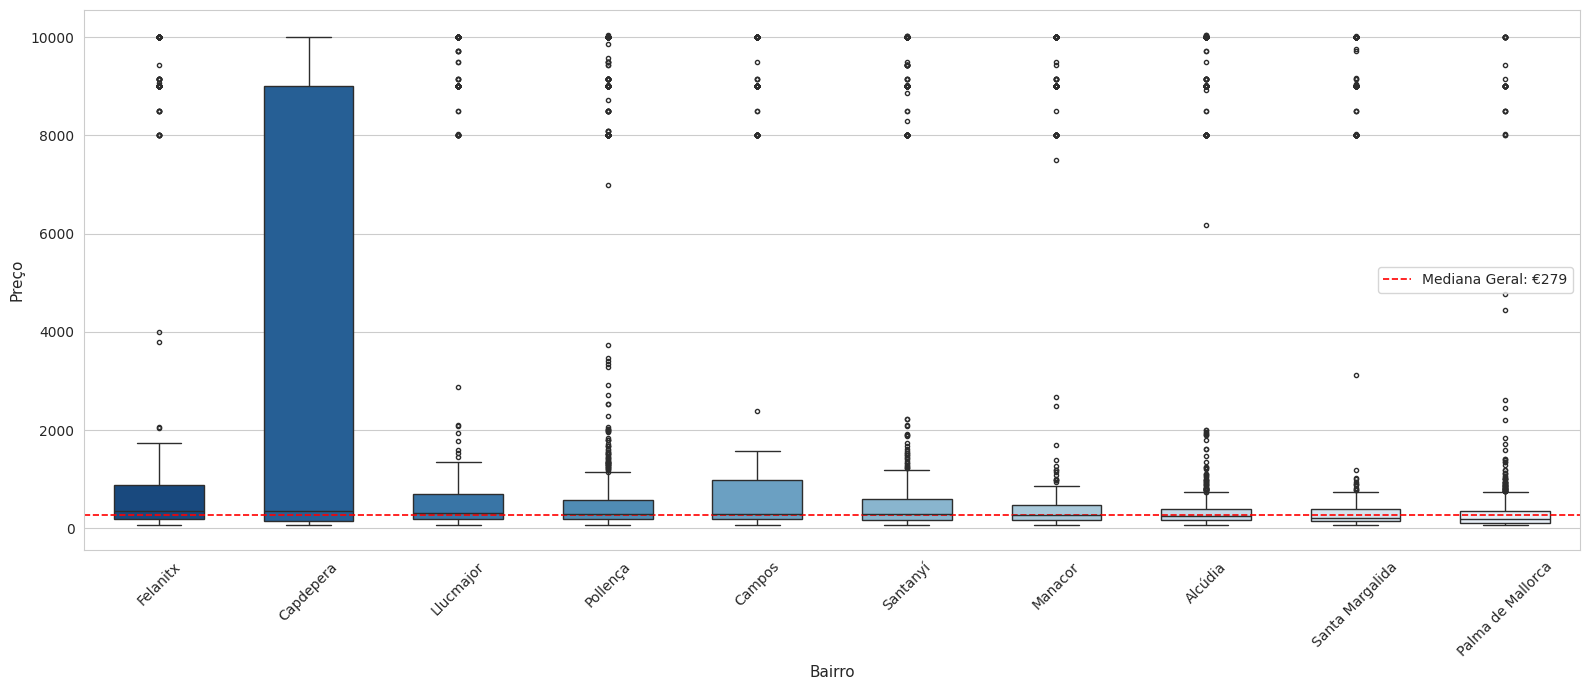

In [76]:
# Vamos mostrar os 10 bairros mais representativos

bairros = df_clean['neighbourhood'].value_counts().head(10).index.to_list()
df_bairros = df_clean[df_clean['neighbourhood'].isin(bairros)].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16,7))

# Cria a ordenação pelo preço da mediana, do mais caro para o mais barato.
ordem = df_bairros.groupby('neighbourhood')['price'].median().sort_values(ascending=False).index

sns.boxplot(
    data = df_bairros,
    x = 'neighbourhood',
    y = 'price',
    order = ordem,
    palette = 'Blues_r',
    width = 0.6,
    fliersize = 3,
    ax = ax
)

ax.set_title('')
ax.set_xlabel('Bairro',fontsize=11)
ax.set_ylabel('Preço',fontsize=11)
ax.tick_params(axis='x',rotation=45)

mediana_geral = df_clean['price'].median()
ax.axhline(mediana_geral, color='red', linestyle='--', linewidth=1.2, label=f'Mediana Geral: €{mediana_geral:.0f}')
ax.legend()
plt.tight_layout()
plt.show()


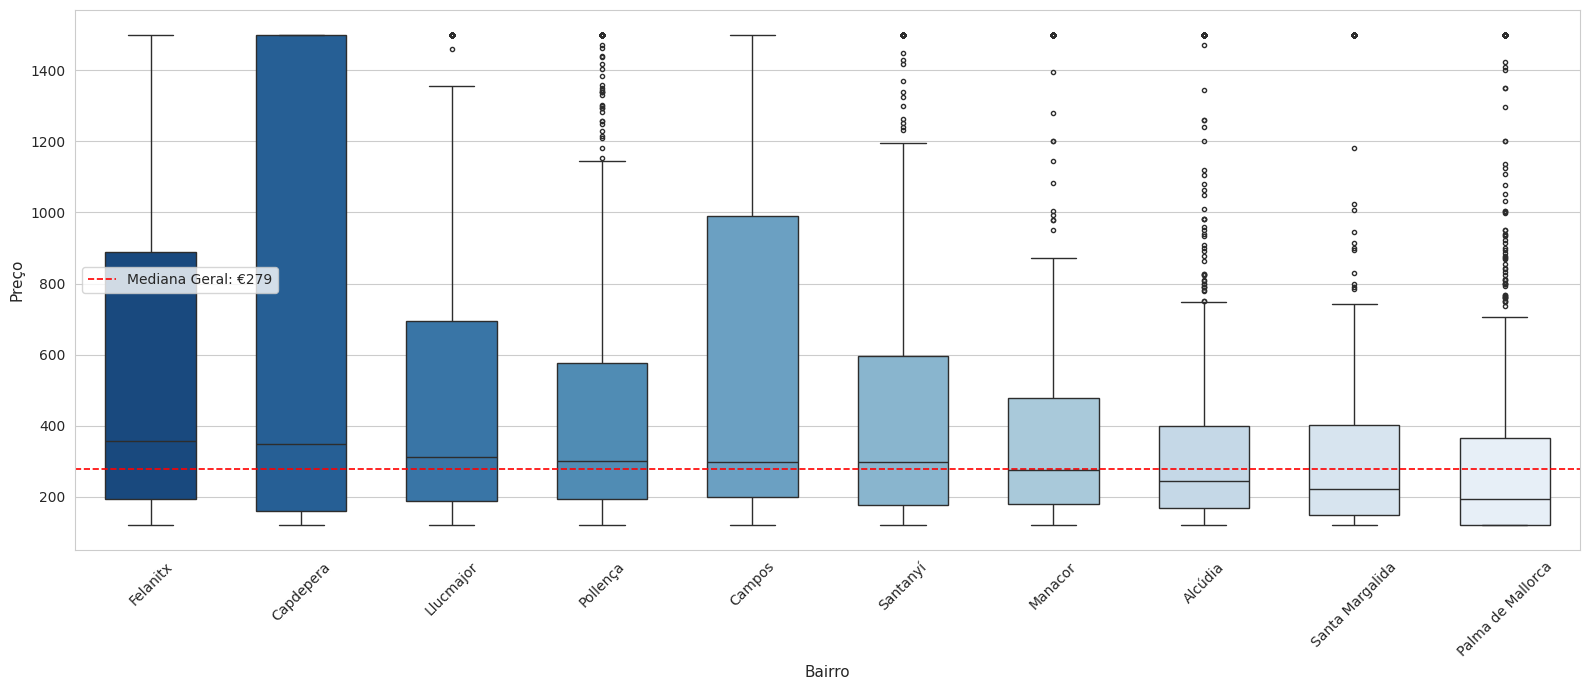

In [79]:
# Vamos mostrar os 10 bairros mais representativos

bairros = df_clean['neighbourhood'].value_counts().head(10).index.to_list()
df_bairros = df_clean[df_clean['neighbourhood'].isin(bairros)].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16,7))

# Cria a ordenação pelo preço da mediana, do mais caro para o mais barato.
ordem = df_bairros.groupby('neighbourhood')['price_winsorizado'].median().sort_values(ascending=False).index

sns.boxplot(
    data = df_bairros,
    x = 'neighbourhood',
    y = 'price_winsorizado',
    order = ordem,
    palette = 'Blues_r',
    width = 0.6,
    fliersize = 3,
    ax = ax
)

ax.set_title('')
ax.set_xlabel('Bairro',fontsize=11)
ax.set_ylabel('Preço',fontsize=11)
ax.tick_params(axis='x',rotation=45)

mediana_geral = df_clean['price_winsorizado'].median()
ax.axhline(mediana_geral, color='red', linestyle='--', linewidth=1.2, label=f'Mediana Geral: €{mediana_geral:.0f}')
ax.legend()
plt.tight_layout()
plt.show()


# **4 - Geo referência dos bairros do Airbnb?**

In [59]:
import plotly.express as px
fig = px.scatter_map(df_clean, lat="latitude", lon="longitude", hover_name="name", hover_data=['neighbourhood','price'],
                        color_discrete_sequence=["#3333cc"], zoom=9, height=400, width=800)
fig.update_layout(map_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

# **5 - Conclusão**

### Estrutura de dados
O dataset fornecido mostra a realidade de imóveis disponíveis para aluguel mensal ou temporada com 18 variáveis que permitem análises ricas em relação a preço, bairros e o anfitrião. Na minha opinião esses dados apresentam situações e problemas reais, ou seja, precisamos tratar os dados antes de qualquer análise e a correlação alta entre dois campos com a maior quantidade de valores ausentes confirmou pela matriz do missingno.

### Preços
Em Mallorca podemos ver uma vasta distribuição de preços com assimetria dos valores, podendo chegar a 10.053 euros por noite. A diferençca grande entre a média e a mediana demonstra exatamente esse problema de assimentria com a presença de outliers. Utilizamos a Winsorização para conter os extremos e tornar a análise mais confiável. Identificamos que preços abaixo de 63 euros não possuem imóveis/quartos disponíveis, sendo valores suspeitos como erro de cadastro, visto que Mallorca é um destino premium europeu.

### Imóveis
Vimos que a maioria dos imóveis disponíveis são do tipo "Entire home/apt" o que faz sentido por se tratar de um destino premium do turismo europeu, sendo considerado alto padrão.

### Bairros
Na análise podemos ver que bairros como Alcúdia, Pollença e Santanyí concentram os preços mais altos o que apresenta a preferência turística por regiões litorâneas com maior concentração na costa norte e leste da ilha.